In [47]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("bro it is working")


from langchain.chat_models import init_chat_model

llm_model = init_chat_model(model="gpt-5-nano")

bro it is working


In [48]:
from pydantic import BaseModel, Field

class strcutredgraph_schema(BaseModel):
    topic: str = Field(description="The topic of for generating the post")
    insta: str 
    twitter: str
    linkedIn: str

In [ ]:
def create_post_insta(schema:strcutredgraph_schema):
    topic = schema.topic
    Llm_Response = llm_model.invoke(f" Write a small insta post about {topic}").content
    return {"insta": Llm_Response}

def create_post_twitter(schema:strcutredgraph_schema):
    topic = schema.topic
    Llm_Response = llm_model.invoke(f" write a small twitter post about {topic}").content
    return {"twitter": Llm_Response}

def create_post_linkedIn(schema:strcutredgraph_schema):
    topic = schema.topic
    Llm_Response = llm_model.invoke(f" write a small linkedIn post about {topic}").content
    return {"linkedIn": Llm_Response}


In [50]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(strcutredgraph_schema)

graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedIn", create_post_linkedIn)

graph.add_edge(START, "create_post_insta")
graph.add_edge(START, "create_post_twitter")
graph.add_edge(START, "create_post_linkedIn")

graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedIn", END)

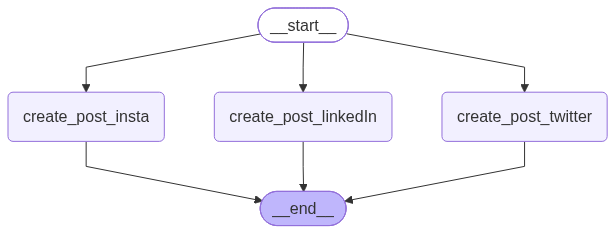

In [51]:
from IPython.display import Image, display

graph = graph.compile()

Image(graph.get_graph().draw_mermaid_png())

In [52]:
graph.invoke({
    "topic" : "Agentic AI",
    "insta" : "",
    "twitter" : "",
    "linkedIn": ""
    })

{'topic': 'Agentic AI',
 'insta': 'Agentic AI is here: machines that not only learn, but act with purpose. A new era of collaboration between human judgment and machine autonomy. Let’s shape it with ethics, transparency, and curiosity. 🤖✨ #AgenticAI #AIethics #FutureOfAI #TechTrends',
 'twitter': 'Agentic AI blends goal-directed action with human oversight—AI that acts with intent, while we steer, correct, and learn together. Responsible autonomy for smarter decisions. #AI #AgenticAI #AIethics',
 'linkedIn': 'Agentic AI is not just smarter assistants—it’s AI that reasons, plans, and acts to achieve defined goals, with human oversight. These autonomous agents can orchestrate data, apps, and workflows to accelerate decisions and scale impact across teams. The upside: faster cycles, deeper automation, and richer collaboration between people and machines. The risks: misalignment, safety, governance, and accountability. The answer isn’t to halt progress, but to design with clear goals, robu